In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, SkyOffsetFrame
import astropy.units as u

         μ_δ        μ_α          δ           α       b-r          g         ϕ  \
0  -3.670401  -3.549444  19.016068  139.049866  1.245728  19.887100 -9.088195   
1  -0.344659 -12.946452  19.128199  138.323669  0.877067  15.293156 -9.767183   
2 -19.620848 -17.365471  18.969149  139.627533  2.183876  19.349550 -8.544322   
3  -2.912975 -12.091125  18.873516  139.590393  1.238544  16.634134 -8.585702   
4  -3.492673 -10.601624  18.798914  138.800568  0.973829  16.150398 -9.339452   

          λ    μ_ϕcosλ        μ_λ  stream   α_wrapped  
0 -4.833090  -3.792117  -3.419100   False  139.049866  
1 -4.672555 -12.936773   0.607710   False  138.323669  
2 -4.916143 -18.591169 -18.463631   False  139.627533  
3 -5.009313 -12.253989  -2.126137   False  139.590393  
4 -5.033384 -10.820551  -2.740231   False  138.800568  
519


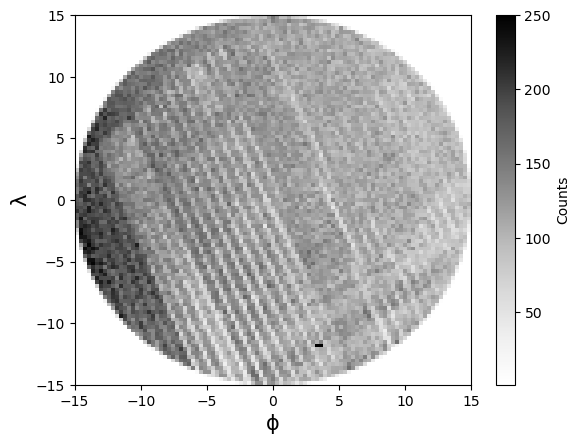

In [18]:
# from paper Github
df_patch1 = pd.read_hdf('gd1_1_patch.h5')
print(df_patch1.head(5))

bins_0 = (np.linspace(-15,15,100), np.linspace(-15,15,100))
plt.hist2d(df_patch1['ϕ'], df_patch1['λ'], cmap='Greys', cmin=1, vmax=250, bins=bins_0)
plt.colorbar(label='Counts')
plt.xlabel('ϕ', fontsize = 15)
plt.ylabel('λ', fontsize = 15)

print((df_patch1['stream'] == True).sum())

In [19]:
df_patch1_true = df_patch1[df_patch1['stream'] == True]
df_patch1_true.head()

,μ_δ,μ_α,δ,α,b-r,g,ϕ,λ,μ_ϕcosλ,μ_λ,stream,α_wrapped
786,-12.710315,-3.318680,18.742863,137.237427,0.888437,20.076353,-10.825115,-4.977279,-4.339457,-12.398986,True,137.237427
9856,-12.324957,-4.929947,18.627661,136.763000,0.704645,20.286083,-11.284292,-5.054853,-5.953947,-11.864209,True,136.763000
9974,-12.368648,-2.895427,18.505676,136.164764,0.759855,19.914282,-11.862099,-5.127258,-3.981333,-12.062998,True,136.164764
10905,-12.593509,-3.634944,18.273092,136.355316,0.646955,19.359943,-11.701794,-5.374863,-4.721927,-12.227538,True,136.355316
11265,-13.434429,-3.199581,18.973757,136.690125,0.623697,19.114992,-11.323846,-4.704155,-4.329684,-13.113926,True,136.690125


In [30]:
for value in df_patch1["α"]:
    if value < 100:
        break
    else:
        continue
    print(value)

         μ_δ    μ_αcosδ          δ           α       b-r          g  \
0  -3.670401  -3.549444  19.016068  139.049866  1.245728  19.887100   
1  -0.344659 -12.946452  19.128199  138.323669  0.877067  15.293156   
2 -19.620848 -17.365471  18.969149  139.627533  2.183876  19.349550   
3  -2.912975 -12.091125  18.873516  139.590393  1.238544  16.634134   
4  -3.492673 -10.601624  18.798914  138.800568  0.973829  16.150398   

                                                                          ϕ  \
0  10.215135 -9.288505  -3.203677  -3.975783 -0.338469  0.747416  10.198720   
1   9.512472 -9.236658 -12.871508  -1.433074  0.851710  0.062273   9.495983   
2  10.770635 -9.284604 -15.421202 -21.183101  0.822432  0.547420  10.754280   
3  10.744390 -9.383141 -11.760524  -4.046082  0.681090  0.100779  10.728032   
4   9.996667 -9.525840 -10.252110  -4.414456  0.609932  0.083251   9.980223   

          λ    μ_ϕcosλ        μ_λ  
0 -9.328097  -3.203808  -3.975678  
1 -9.276225 -12.871567  -1

Text(0, 0.5, 'λ')

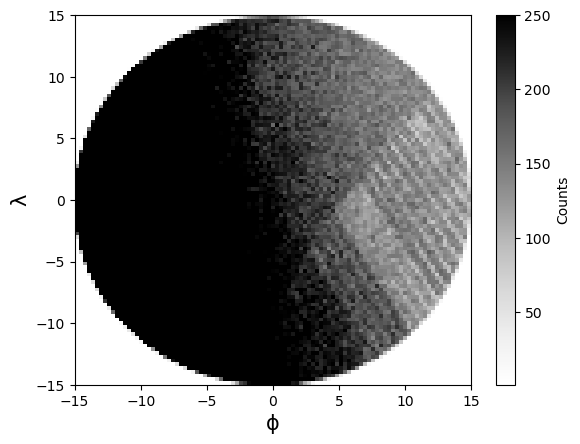

In [20]:
# load one of 21 GD-1 inclusive patches
updatedcolnames = ["μ_δ", "μ_αcosδ", "δ", "α", "b-r", "g", "", "", "", "", "", ""]
df_patch1data = pd.DataFrame(np.load('gaiascan_l195.0_b33.7_ra128.4_dec28.8.npy'), columns = updatedcolnames)

# rotate RA, dec, pmra, pmdec coordinates
patch_center = SkyCoord(ra=128.4*u.deg, dec=28.8*u.deg)

frame = SkyOffsetFrame(origin=patch_center)

coords = SkyCoord(
    ra=df_patch1data.loc[:,'α'].to_numpy()*u.deg,
    dec=df_patch1data.loc[:,'δ'].to_numpy()*u.deg,
    pm_ra_cosdec=df_patch1data.loc[:, 'μ_αcosδ'].to_numpy()*u.mas/u.yr,
    pm_dec=df_patch1data.loc[:,'μ_δ'].to_numpy()*u.mas/u.yr
)

rot = coords.transform_to(frame)

phi = rot.lon.degree
lam = rot.lat.degree
mu_phi_star = rot.pm_lon_coslat.value
mu_lambda = rot.pm_lat.value

df_patch1data.loc[:, 'ϕ'] = phi
df_patch1data.loc[:, 'λ'] = lam
df_patch1data.loc[:, 'μ_ϕcosλ'] = mu_phi_star
df_patch1data.loc[:, 'μ_λ'] = mu_lambda

print(df_patch1data.head())

bins_0 = (np.linspace(-15,15,100), np.linspace(-15,15,100))
plt.hist2d(df_patch1data['ϕ'], df_patch1data['λ'], cmap='Greys', cmin=1, vmax=250, bins=bins_0)
plt.colorbar(label='Counts')
plt.xlabel('ϕ', fontsize = 15)
plt.ylabel('λ', fontsize = 15)

In [21]:
colnames = ["pmdec", "pmra", "dec", "ra", "b-r", "g", "rotra", "rotdec", "rotpmra", "rotpmdec", "del1", "del2"]
df_data = pd.DataFrame(np.load('gaiascan_l195.0_b33.7_ra128.4_dec28.8.npy'), columns = colnames)
df_patch = df_data.drop(columns=['del1','del2'])
df_patch.head()
df_patch.to_hdf('df_patch.h5', key='df_patch', mode='w')

In [25]:
h5df = pd.read_hdf('df_patch.h5', key='df_patch')
h5df.head()

,pmdec,pmra,dec,ra,b-r,g,rotra,rotdec,rotpmra,rotpmdec
0,-3.670401,-3.549444,19.016068,139.049866,1.245728,19.887100,10.215135,-9.288505,-3.203677,-3.975783
1,-0.344659,-12.946452,19.128199,138.323669,0.877067,15.293156,9.512472,-9.236658,-12.871508,-1.433074
2,-19.620848,-17.365471,18.969149,139.627533,2.183876,19.349550,10.770635,-9.284604,-15.421202,-21.183101
3,-2.912975,-12.091125,18.873516,139.590393,1.238544,16.634134,10.744390,-9.383141,-11.760524,-4.046082
4,-3.492673,-10.601624,18.798914,138.800568,0.973829,16.150398,9.996667,-9.525840,-10.252110,-4.414456


In [28]:
patch_list = [
     # b = 33.7 
     'gaiascan_l195.0_b33.7_ra128.4_dec28.8.npy', # centered at (128.4, 28.8)
     'gaiascan_l210.0_b33.7_ra132.6_dec16.9.npy', 
     'gaiascan_l225.0_b33.7_ra138.1_dec5.7.npy', 
     # b = 41.8 
     'gaiascan_l187.5_b41.8_ra136.5_dec36.1.npy',
     'gaiascan_l202.5_b41.8_ra138.8_dec25.1.npy',
     'gaiascan_l217.5_b41.8_ra142.7_dec14.5.npy', 
     # b = 50.2 
     'gaiascan_l99.0_b50.2_ra224.7_dec60.6.npy',
     'gaiascan_l117.0_b50.2_ra202.4_dec66.5.npy',
     'gaiascan_l135.0_b50.2_ra174.3_dec65.1.npy',
     'gaiascan_l153.0_b50.2_ra156.2_dec57.5.npy',
     'gaiascan_l171.0_b50.2_ra148.6_dec47.0.npy',
     'gaiascan_l189.0_b50.2_ra146.9_dec35.6.npy',
     'gaiascan_l207.0_b50.2_ra148.6_dec24.2.npy',
     # b = 58.4 
     'gaiascan_l101.2_b58.4_ra212.7_dec55.2.npy',
     'gaiascan_l123.8_b58.4_ra192.0_dec58.7.npy',
     'gaiascan_l146.2_b58.4_ra171.8_dec54.7.npy',
     'gaiascan_l168.8_b58.4_ra160.5_dec45.5.npy',
     'gaiascan_l191.2_b58.4_ra156.9_dec34.1.npy',
     # b = 66.4 
     'gaiascan_l105.0_b66.4_ra203.7_dec49.1.npy',
     'gaiascan_l135.0_b66.4_ra185.4_dec50.0.npy',
     'gaiascan_l165.0_b66.4_ra171.4_dec43.0.npy',    
    ]
    
for p in patch_list:
    patch = np.load(p)
    colnames = ["pmdec", "pmra", "dec", "ra", "b-r", "g",
                "rotra", "rotdec", "rotpmra", "rotpmdec", "del1", "del2"]
    df = pd.DataFrame(patch, columns=colnames)
    print(p)
    for value in df['ra']:
        if value < 100:
            break
        else:
            continue
        print(value)

gaiascan_l195.0_b33.7_ra128.4_dec28.8.npy
gaiascan_l210.0_b33.7_ra132.6_dec16.9.npy
gaiascan_l225.0_b33.7_ra138.1_dec5.7.npy
gaiascan_l187.5_b41.8_ra136.5_dec36.1.npy
gaiascan_l202.5_b41.8_ra138.8_dec25.1.npy
gaiascan_l217.5_b41.8_ra142.7_dec14.5.npy
gaiascan_l99.0_b50.2_ra224.7_dec60.6.npy
gaiascan_l117.0_b50.2_ra202.4_dec66.5.npy
gaiascan_l135.0_b50.2_ra174.3_dec65.1.npy
gaiascan_l153.0_b50.2_ra156.2_dec57.5.npy
gaiascan_l171.0_b50.2_ra148.6_dec47.0.npy
gaiascan_l189.0_b50.2_ra146.9_dec35.6.npy
gaiascan_l207.0_b50.2_ra148.6_dec24.2.npy
gaiascan_l101.2_b58.4_ra212.7_dec55.2.npy
gaiascan_l123.8_b58.4_ra192.0_dec58.7.npy
gaiascan_l146.2_b58.4_ra171.8_dec54.7.npy
gaiascan_l168.8_b58.4_ra160.5_dec45.5.npy
gaiascan_l191.2_b58.4_ra156.9_dec34.1.npy
gaiascan_l105.0_b66.4_ra203.7_dec49.1.npy
gaiascan_l135.0_b66.4_ra185.4_dec50.0.npy
gaiascan_l165.0_b66.4_ra171.4_dec43.0.npy


In [9]:
# colnames = ["μ_δ", "μ_α", "δ", "α", "b-r", "g", "ϕ", "λ", "μ_ϕcosλ", "μ_λ", "del1", "del2"]
# df_datacheck = pd.DataFrame(np.load('gaiascan_l195.0_b33.7_ra128.4_dec28.8.npy'), columns = colnames)
# len(df_datacheck)

# del2col = df_datacheck['del2']
# del2high = []
# for no in del2col:
#     if no > 1:
#         del2high.append(no)
#     else:
#         continue
# print(del2high)

In [1]:
# from astropy.table import Table
# tbl = Table.read('gd1-with-masks.fits')
# tbl = tbl[tbl['pm_mask'] & tbl['gi_cmd_mask'] & tbl['stream_track_mask']]
# np.save('gd1tbl.npy', tbl.as_array())

In [3]:
# from tqdm import tqdm

# colnames = ["μ_δ", "μ_α", "δ", "α", "b-r", "g", "ϕ", "λ", "μ_ϕcosλ", "μ_λ", "del1", "del2"]
# df_crosscheck = pd.DataFrame(np.load('gaiascan_l207.0_b50.2_ra148.6_dec24.2.npy'), columns = colnames)

# def angular_distance(angle1,angle2): # function from David's file via_machinae.py, needed for FilterGD1 function
#     # inputs are np arrays of [ra,dec]
#     deltara=np.minimum(np.minimum(np.abs(angle1[:,0]-angle2[:,0]+360),np.abs(angle1[:,0]-angle2[:,0])),\
#                           np.abs(angle1[:,0]-angle2[:,0]-360))
#     deltadec=np.abs(angle1[:,1]-angle2[:,1])
#     return np.sqrt(deltara**2+deltadec**2)
    
# def FilterGD1(stars, gd1_stars):
#     gd1stars=np.zeros(len(stars))
#     for star in tqdm(gd1_stars):
#         ra=star['ra']
#         dec=star['dec']
#         pmra=star['pmra']
#         pmdec=star['pmdec']
#         foundlist=angular_distance(np.dstack((stars[:,3],stars[:,2]))[0],np.array([[ra,dec]]))
#         foundlist=np.sqrt(foundlist**2+(stars[:,0]-pmdec)**2+(stars[:,1]-pmra)**2)   
#         foundlist=foundlist<.0001
#         if len(np.argwhere(foundlist))>1:
#             print(foundlist)
#         if len(np.argwhere(foundlist))==1:
#             gd1stars+=foundlist
#     gd1stars=gd1stars.astype('bool')
#     return gd1stars,stars[gd1stars]

# gd1 = np.load("gd1tbl.npy")

# is_stream, stream = FilterGD1(np.array(df_crosscheck), gd1)
# df_crosscheck["stream"] = is_stream

# print((df_crosscheck['stream'] == True).sum())

In [5]:
# df_true = df_crosscheck[df_crosscheck['stream'] == True]
# df_true.head()

In [11]:
# patch_list = [
#      # b = 33.7 
#      'gaiascan_l195.0_b33.7_ra128.4_dec28.8.npy', # centered at (128.4, 28.8)
#      'gaiascan_l210.0_b33.7_ra132.6_dec16.9.npy', 
#      'gaiascan_l225.0_b33.7_ra138.1_dec5.7.npy', 
#      # b = 41.8 
#      'gaiascan_l187.5_b41.8_ra136.5_dec36.1.npy',
#      'gaiascan_l202.5_b41.8_ra138.8_dec25.1.npy',
#      'gaiascan_l217.5_b41.8_ra142.7_dec14.5.npy', 
#      # b = 50.2 
#      'gaiascan_l99.0_b50.2_ra224.7_dec60.6.npy',
#      'gaiascan_l117.0_b50.2_ra202.4_dec66.5.npy',
#      'gaiascan_l135.0_b50.2_ra174.3_dec65.1.npy',
#      'gaiascan_l153.0_b50.2_ra156.2_dec57.5.npy',
#      'gaiascan_l171.0_b50.2_ra148.6_dec47.0.npy',
#      'gaiascan_l189.0_b50.2_ra146.9_dec35.6.npy',
#      'gaiascan_l207.0_b50.2_ra148.6_dec24.2.npy',
#      # b = 58.4 
#      'gaiascan_l101.2_b58.4_ra212.7_dec55.2.npy',
#      'gaiascan_l123.8_b58.4_ra192.0_dec58.7.npy',
#      'gaiascan_l146.2_b58.4_ra171.8_dec54.7.npy',
#      'gaiascan_l168.8_b58.4_ra160.5_dec45.5.npy',
#      'gaiascan_l191.2_b58.4_ra156.9_dec34.1.npy',
#      # b = 66.4 
#      'gaiascan_l105.0_b66.4_ra203.7_dec49.1.npy',
#      'gaiascan_l135.0_b66.4_ra185.4_dec50.0.npy',
#      'gaiascan_l165.0_b66.4_ra171.4_dec43.0.npy',    
#     ]

# for p in patch_list:
#     patch = np.load(p)
#     df_patchcheck = pd.DataFrame(patch, columns=colnames)
#     print(p)
#     print(len(df_patchcheck))
#     print(df_patchcheck.head())

In [13]:
# patch_list = [
#      # b = 33.7 
#      'gaiascan_l195.0_b33.7_ra128.4_dec28.8.npy', # centered at (128.4, 28.8)
#      'gaiascan_l210.0_b33.7_ra132.6_dec16.9.npy', 
#      'gaiascan_l225.0_b33.7_ra138.1_dec5.7.npy', 
#      # b = 41.8 
#      'gaiascan_l187.5_b41.8_ra136.5_dec36.1.npy',
#      'gaiascan_l202.5_b41.8_ra138.8_dec25.1.npy',
#      'gaiascan_l217.5_b41.8_ra142.7_dec14.5.npy', 
#      # b = 50.2 
#      'gaiascan_l99.0_b50.2_ra224.7_dec60.6.npy',
#      'gaiascan_l117.0_b50.2_ra202.4_dec66.5.npy',
#      'gaiascan_l135.0_b50.2_ra174.3_dec65.1.npy',
#      'gaiascan_l153.0_b50.2_ra156.2_dec57.5.npy',
#      'gaiascan_l171.0_b50.2_ra148.6_dec47.0.npy',
#      'gaiascan_l189.0_b50.2_ra146.9_dec35.6.npy',
#      'gaiascan_l207.0_b50.2_ra148.6_dec24.2.npy',
#      # b = 58.4 
#      'gaiascan_l101.2_b58.4_ra212.7_dec55.2.npy',
#      'gaiascan_l123.8_b58.4_ra192.0_dec58.7.npy',
#      'gaiascan_l146.2_b58.4_ra171.8_dec54.7.npy',
#      'gaiascan_l168.8_b58.4_ra160.5_dec45.5.npy',
#      'gaiascan_l191.2_b58.4_ra156.9_dec34.1.npy',
#      # b = 66.4 
#      'gaiascan_l105.0_b66.4_ra203.7_dec49.1.npy',
#      'gaiascan_l135.0_b66.4_ra185.4_dec50.0.npy',
#      'gaiascan_l165.0_b66.4_ra171.4_dec43.0.npy',    
#     ]
    
# for p in patch_list:
#     patch = np.load(p)
#     df = pd.DataFrame(patch)
#     print(p)
#     print(df.head())